In [1]:
# Ruta del directorio actual
import os; ruta_actual = os.getcwd(); os.startfile(ruta_actual)

## MODELO DE FLUJO Y TRANSPORTE UTILIZANDO GWF y MT3D-USGS
## Modelación de las especies: sulfato $c_1= SO_4^{2-}$ y calcio $c_2 = Ca^{2+}$
### Flujo y transporte sin y con RCT en 1D utilizando GWF, MT3D-USGS y Flopy

$$\frac{\partial}{\partial x}( K \frac{\partial h }{\partial x})+ q_s = S_s \frac{\partial h }{\partial t} \tag{1} $$

$$\frac {\partial\left(\theta C^k\right)}{\partial t}  = \frac{\partial}{\partial x}\left(\theta D \frac{\partial C^k}{\partial x}\right)- \frac{\partial}{\partial x} (\theta v C^k) + q_s C^{k}_{s} \tag{2} $$


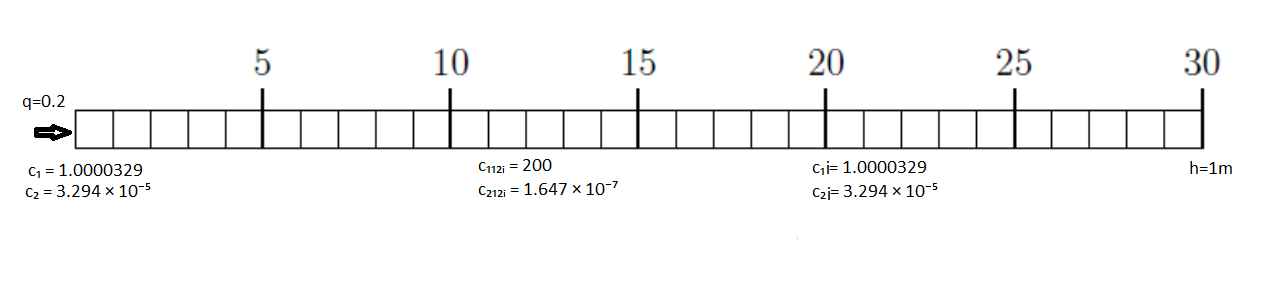

In [3]:
# insertar imagen incrustada en base64 dentro del notebook
from IPython.display import HTML
import base64
# Ruta de tu imagen
image_path = "dominio1.png"
# Leer imagen como base64
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")
# HTML para incrustar la imagen
html = f'<img src="data:image/png;base64,{image_base64}" />'
# Mostrar imagen
HTML(html)

## DESCRIPCIÓN DEL MODELO GWF-MT3D-USGS
* **Problema de flujo 1D**
* con las siguientes dimensiones del dominio: 
* LX=30 m, LY=1 m, LZ=1 m
* considerando las siguientes condiciones de frontera:
* Flujo prescrito en la frontera izquierda CFI= 0.2 m3/d
* Carga prescrita en la frontera derecha CFD=1m  

* **Problema de transporte 1D**
* Se consideran dos especies con las siguientes condiciones de frontera y condiciones iniciales:
* **Especie 1: c1 (sulfato)**
* Concentración en el flujo de entrada: c₁ = 1.0000329
* Concentración inicial c1i = 1.0000329 en todo el dominio, excepto en la celda 12, donde c₁₁₂ᵢ = 200
* **Especie 2: c2 (calcio)**
* Concentración en el flujo de entrada: c₂ = 3.294 × 10⁻⁵
* Concentración inicial  c₂ᵢ: 3.294 × 10⁻⁵ en todo el dominio, excepto en la celda 12, donde c₂₁₂ᵢ = 1.647 × 10⁻⁷
* Estas concentraciones fueron calculadas usando la ley de acción de masas, con:
* c₂ᵢ = Kₑ / c₁ᵢ = 3.29382 × 10⁻⁵ / 1.0000329 = 3.294 × 10⁻⁵  
* c₂₁₂ᵢ = 3.29382 × 10⁻⁵ / 200 = 1.647 × 10⁻⁷

* **Las propiedades físicas del problema son**:
* Conductividad hidráulica = 1.0 m/día
* Porosidad = 0.5
* Dispersividad longitudinal =0.2
* Factor de retardación =1.0
* Se simulan 40 días en 40 pasos de tiempo


## 1. Preparación del entorno

In [6]:
# Preparación del entorno
import os, sys #Permite interactuar con el sistema operativo, y al intérprete de Python
import numpy as np #Proporciona estructuras y operaciones matemáticas de alto rendimiento.
import flopy
import matplotlib.pyplot as plt
from flopy.utils.binaryfile import HeadFile, CellBudgetFile, UcnFile
from flopy.plot.styles import styles
import pandas as pd # Facilita la manipulación y análisis de datos en estructuras tabulares.

# --- Definición de rutas ---
base_dir = os.getcwd()               # Directorio actual de trabajo
workspace = os.path.join(base_dir, "flow_transport")  # Carpeta para guardar archivos flow_transport
exe_dir = os.path.join(base_dir, "EXE")               # Carpeta con ejecutables
os.makedirs(workspace, exist_ok=True)                 # Crear "flow_transport" si no existe

# --- Ejecutables ---
mf6_exe = os.path.join(exe_dir, "mf6.exe")
mt3d_exe = os.path.join(exe_dir, "mt3d-usgs_1.1.0_64.exe")

# --- Nombres de los archivos del modelo  ---
sim_name = "flow_transport" # Nombre de la simulación
flow_name = "flow" # Nombre archivos de flujo
transport_name = "transport" # Nombre archivos de transporte
print(mf6_exe)

C:\Users\NRBRT\clone\WMACC\DESARROLLO_MODELOS\GWF-MT3D-USGS\R1-GWF-MT3D-USGS\VERSIONES-0\CICLO\EXE\mf6.exe


## 2. Construcción del modelo de flujo (MODFLOW 6)

In [8]:
# Se define la simulación MFSimulation con nombre, ruta de trabajo y ejecutable mf6.
sim = flopy.mf6.MFSimulation(sim_name=sim_name, sim_ws=workspace, exe_name=mf6_exe)

# Se configura el tiempo total de 40 días con 40 pasos de 1 día cada uno.
tdis = flopy.mf6.ModflowTdis(sim, time_units="days", perioddata=[(1.0, 1, 1.0)]) # (perlen,nstp,1.0)

# Se incluye un iterative model solution (ModflowIms) para resolver el modelo.
ims = flopy.mf6.ModflowIms(sim, pname="ims")

# Se crea el modelo de flujo subterráneo (GWF) asociado a la simulación.
gwf = flopy.mf6.ModflowGwf(sim, modelname=flow_name, save_flows=True)

# Se define una malla de 1 capa, 1 fila, 31 columnas, con celdas de 1 metro de tamaño.
dis = flopy.mf6.ModflowGwfdis(gwf, nlay=1, nrow=1, ncol=31, delr=1.0, delc=1.0, top=1.0, botm=[0.0])

# Se establece una carga inicial de 1.0 en toda la malla.
ic = flopy.mf6.ModflowGwfic(gwf, strt=1.0)

# Se asigna una conductividad hidráulica de 1.0 m/día y se activa el cálculo del flujo específico.
npf = flopy.mf6.ModflowGwfnpf(gwf, icelltype=0, k=1.0, save_flows=True, save_specific_discharge=True)

# Se impone una carga fija de 1.0 en la celda del extremo derecho (columna 30).
chd_spd = [[(0, 0, 30), 1.0]]
chd = flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chd_spd)

# Se coloca un pozo en la columna 0 que inyecta agua con un caudal de 0.2 y concentraciones c1 y c2
c1 = 1.0000329 # sulfato
c2 = 3.294e-5  # calcio
wel_spd = [[(0, 0, 0), 0.2, c1, c2]]
wel = flopy.mf6.ModflowGwfwel(gwf, stress_period_data=wel_spd, auxiliary=["CONC_ESP_1", "CONC_ESP_2"])

# Se configuran archivos de salida para cargas (.hds) y balance (.bud), guardando e imprimiendo todo.
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{flow_name}.hds",
    budget_filerecord=f"{flow_name}.bud",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "ALL"), ("BUDGET", "ALL")]
)

# Se guardan todos los archivos necesarios para ejecutar la simulación en el directorio especificado.
sim.write_simulation()
print(f"Archivos de flujo escritos en {workspace}")


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package chd_0...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 1 based on size of stress_period_data
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
Archivos de flujo escritos en C:\Users\NRBRT\clone\WMACC\DESARROLLO_MODELOS\GWF-MT3D-USGS\R1-GWF-MT3D-USGS\VERSIONES-0\CICLO\flow_transport


## 3. Ejecución del modelo de flujo

In [10]:
success, buff = sim.run_simulation()
if success:
    print("✅ Simulación de flujo ejecutada exitosamente.")
else:
    print("❌ Error en la simulación de flujo.")
    print(buff.decode())


FloPy is using the following executable to run the model: ..\EXE\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.4.2 06/28/2023

   MODFLOW 6 compiled Jun 28 2023 18:41:13 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Government shall be

## 4. Visualización de resultados (Carga hidráulica)

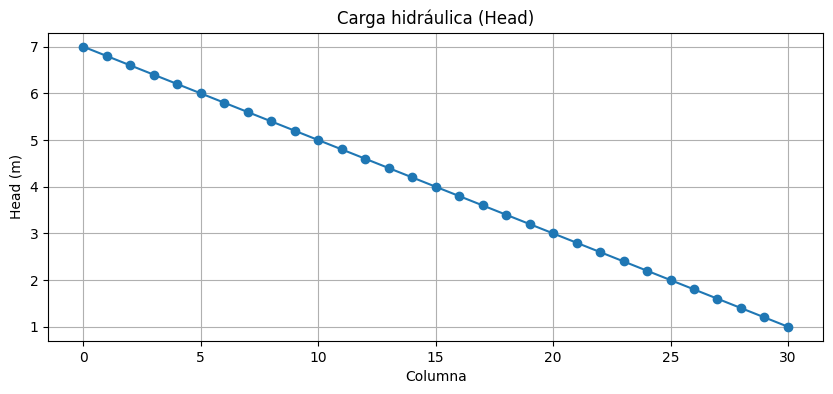

In [12]:
# --- Cargar HEADS ---
headfile = os.path.join(workspace, f"{flow_name}.hds")
headobj = HeadFile(headfile)
times = headobj.get_times()
head = headobj.get_data(totim=times[-1])

# --- Graficar ---
plt.figure(figsize=(10, 4))
plt.plot(np.arange(head.shape[-1]), head[0, 0, :], marker='o')
plt.title("Carga hidráulica (Head)")
plt.xlabel("Columna")
plt.ylabel("Head (m)")
plt.grid(True)
plt.show()


## 5. Visualización (Descarga específica qx)

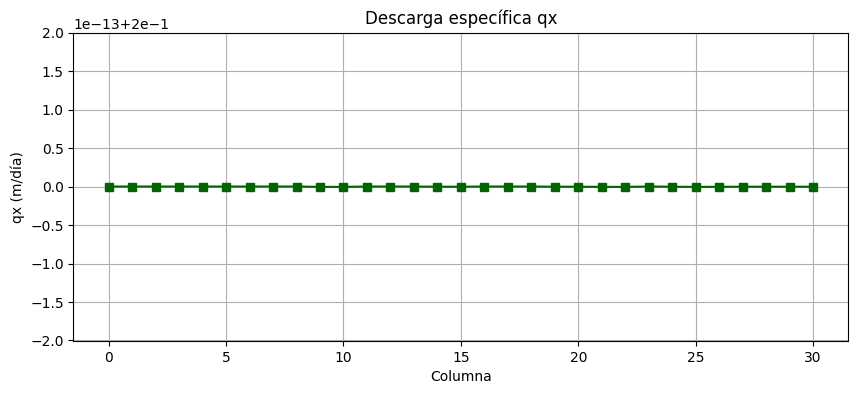

In [14]:
# --- Cargar descarga específica ---
budfile = os.path.join(workspace, f"{flow_name}.bud") # Ruta del archivo .bud.
cbb = CellBudgetFile(budfile, precision='double') # Carga archivo de balance con doble precisión.
spdis = cbb.get_data(text='DATA-SPDIS')[0] # Extrae flujo específico del primer tiempo.
qx = spdis['qx'].flatten() # Lista del flujo en x (qx) a 1D.

# --- Graficar ---
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(qx)), qx, marker='s', color='darkgreen')
plt.title("Descarga específica qx")
plt.xlabel("Columna")
plt.ylabel("qx (m/día)")
plt.grid(True)
plt.show()


## XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX